# 2. Population & risk insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #to get the %

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
train = pd.read_csv('../data/train_clean.csv', index_col=0)

In [4]:
print(f"shape: {train.shape}  |  default rate: {train['SeriousDlqin2yrs'].mean():.2%}")

shape: (149998, 12)  |  default rate: 6.68%


## a. Population profile

                                    mean      50%   min          max  missing_%
age                                52.30    52.00 21.00       109.00       0.00
MonthlyIncome                   6,670.23 5,400.00  0.00 3,008,750.00      19.82
NumberOfDependents                  0.76     0.00  0.00        13.00       2.62
NumberOfOpenCreditLinesAndLoans     8.45     8.00  0.00        58.00       0.00
NumberRealEstateLoansOrLines        1.02     1.00  0.00        54.00       0.00


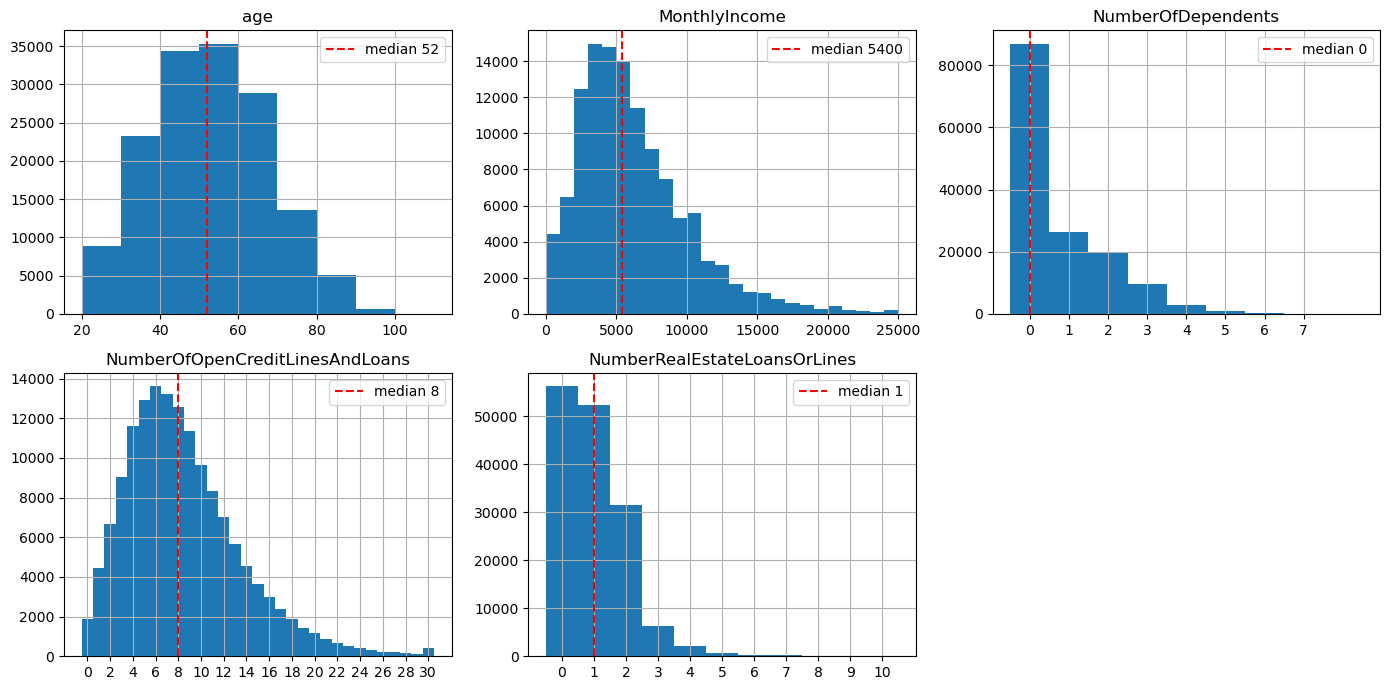

In [5]:
CONFIG = {
    'age':                             dict(bins=range(20, 120, 10)),
    'MonthlyIncome':                   dict(bins=np.arange(0, 26000, 1000), cap=25000),
    'NumberOfDependents':              dict(bins=np.arange(-0.5, 9),  clip=7,  xticks=range(0, 8)),
    'NumberOfOpenCreditLinesAndLoans': dict(bins=np.arange(-0.5, 31), clip=30, xticks=range(0, 31, 2)),
    'NumberRealEstateLoansOrLines':    dict(bins=np.arange(-0.5, 11), clip=10, xticks=range(0, 11)),
}
cols = list(CONFIG)
profile = train[cols].describe(percentiles=[.5]).T[['mean', '50%', 'min', 'max']]
profile['missing_%'] = train[cols].isna().mean() * 100
print(profile.round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, ax in zip(cols, axes.ravel()):
    cfg = CONFIG[col]
    train[col].clip(upper=cfg.get('clip')).hist(bins=cfg['bins'], ax=ax)
    med = train[col].median()
    ax.axvline(med, color='red', ls='--', lw=1.5, label=f'median {med:g}')
    if 'xticks' in cfg:
        ax.set_xticks(cfg['xticks'])
    ax.set_title(col)
    ax.legend()

axes.ravel()[len(cols)].axis('off')   # hide the empty 6th panel
plt.tight_layout()
plt.show()

                                    mean      50%   min        max  missing_%
age                                45.93    45.00 21.00     101.00       0.00
MonthlyIncome                   5,630.83 4,500.00  0.00 250,000.00      16.65
NumberOfDependents                  0.95     0.00  0.00       8.00       1.79
NumberOfOpenCreditLinesAndLoans     7.88     7.00  0.00      57.00       0.00
NumberRealEstateLoansOrLines        0.99     1.00  0.00      29.00       0.00


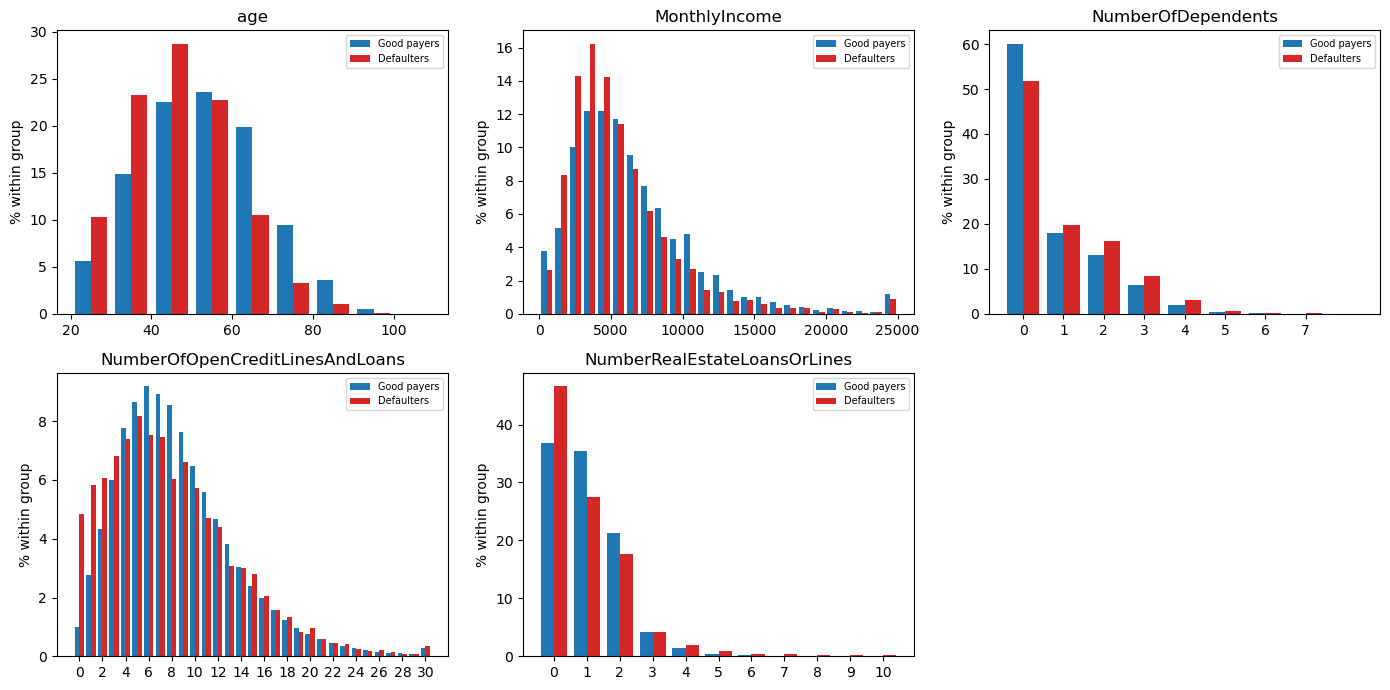

In [9]:
goods      = train[train["SeriousDlqin2yrs"] == 0]
defaulters = train[train["SeriousDlqin2yrs"] == 1]

CONFIG = {
    'age':                             dict(bins=range(20, 120, 10)),
    'MonthlyIncome':                   dict(bins=np.arange(0, 26000, 1000), cap=25000),
    'NumberOfDependents':              dict(bins=np.arange(-0.5, 9),  clip=7,  xticks=range(0, 8)),
    'NumberOfOpenCreditLinesAndLoans': dict(bins=np.arange(-0.5, 31), clip=30, xticks=range(0, 31, 2)),
    'NumberRealEstateLoansOrLines':    dict(bins=np.arange(-0.5, 11), clip=10, xticks=range(0, 11)),
}
cols = list(CONFIG)

profile = defaulters[cols].describe(percentiles=[.5]).T[['mean', '50%', 'min', 'max']]
profile['missing_%'] = defaulters[cols].isna().mean() * 100
print(profile.round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, ax in zip(cols, axes.ravel()):
    cfg = CONFIG[col]
    bins = np.asarray(cfg['bins'], dtype=float)
    clip = cfg.get('cap', cfg.get('clip'))
    g = goods[col].clip(upper=clip).dropna()
    b = defaulters[col].clip(upper=clip).dropna()
    # normalize to % within each group
    gh, edges = np.histogram(g, bins=bins); gh = gh / gh.sum() * 100
    bh, _     = np.histogram(b, bins=bins); bh = bh / bh.sum() * 100
    centers = (edges[:-1] + edges[1:]) / 2
    width = edges[1] - edges[0]
    ax.bar(centers - width * 0.2, gh, width=width * 0.4, color="#1f77b4", label="Good payers")
    ax.bar(centers + width * 0.2, bh, width=width * 0.4, color="#d62728", label="Defaulters")
    if 'xticks' in cfg:
        ax.set_xticks(cfg['xticks'])
    ax.set_title(col)
    ax.set_ylabel("% within group")
    ax.legend(fontsize=7)
axes.ravel()[len(cols)].axis('off')   # hide the empty 6th panel
plt.tight_layout()
plt.show()